# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: cpu | torch 2.14.0+cu130


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [ ]:
# Пиксели остаются в диапазоне [0, 1] (без нормализации) — так удобнее задавать ограничения атак
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(f"train: {len(train_dataset)}, test: {len(test_dataset)}")

train: 60000, test: 10000


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class TargetCNN(nn.Module):
    """Целевая модель («чёрный ящик»): 2 свёрточных слоя + max pooling + полносвязный классификатор."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 32x14x14
        x = self.pool(F.relu(self.conv2(x)))   # -> 64x7x7
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
target_model = TargetCNN().to(device)
opt = torch.optim.Adam(target_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

n_epochs = 3
for epoch in range(n_epochs):
    target_model.train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = target_model(xb)
        loss = crit(out, yb)
        loss.backward()
        opt.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    print(f"Эпоха {epoch + 1}: loss = {running_loss / total:.4f}, "
          f"train acc = {correct / total:.4f}, время {time.time() - t0:.1f} c")
target_model.eval();

Эпоха 1: loss = 0.2553, train acc = 0.9240, время 32.2 c


Эпоха 2: loss = 0.0614, train acc = 0.9810, время 31.0 c


Эпоха 3: loss = 0.0419, train acc = 0.9874, время 32.4 c


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total

clean_accuracy = evaluate(target_model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9887


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [ ]:
class QueryCounter:
    """Обёртка-оракул над целевой моделью. Каждый вызов увеличивает n_queries на размер батча."""
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.n_queries = 0

    def reset(self):
        self.n_queries = 0

    @staticmethod
    def _to_batch(x):
        x = torch.as_tensor(x).detach().float()
        if x.dim() == 2:          # 28x28
            x = x.unsqueeze(0)
        if x.dim() == 3:          # 1x28x28 -> 1x1x28x28
            x = x.unsqueeze(0)
        return x.to(device)

    def logits(self, x):
        x = self._to_batch(x)
        self.n_queries += x.shape[0]
        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        # softmax считаем в float64, чтобы маленькие вероятности не обнулялись
        return F.softmax(self.logits(x).double(), dim=1)

    def label(self, x):
        return self.logits(x).argmax(dim=1)

oracle = QueryCounter(target_model)

# Отдельный «оценочный» оракул: используется только для измерения метрик для отчёта
# (например, согласия суррогата с целью на тесте) и не входит в бюджет запросов атак.
eval_oracle = QueryCounter(target_model)

## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

In [ ]:
class SubstituteMLP(nn.Module):
    """Суррогат: полносвязная сеть (в отличие от свёрточной TargetCNN)."""
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 10),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
oracle.reset()
n_seed_per_class = 20
n_seed = n_seed_per_class * 10

# Берём n_seed = 20*10 случайных изображений из train_dataset (в среднем ~20 на класс).
# Метки датасета НЕ используются — только пиксели; разметку даёт оракул.
rng = np.random.RandomState(RANDOM_STATE)
seed_idx = rng.choice(len(train_dataset), n_seed, replace=False)
substitute_data = torch.stack([train_dataset[i][0] for i in seed_idx]).to(device)
oracle_labels = oracle.label(substitute_data)

print(f"Начальный набор: {len(substitute_data)} изображений, запросов к оракулу = {oracle.n_queries}")
print("Распределение меток оракула по классам:", torch.bincount(oracle_labels, minlength=10).tolist())

Начальный набор: 200 изображений, запросов к оракулу = 200
Распределение меток оракула по классам: [21, 21, 21, 18, 24, 18, 16, 16, 26, 19]


In [ ]:
def jacobian_augmentation(model, x, labels, lam=0.1):
    """Якобиан-аугментация Papernot et al.: сдвиг каждой точки на lam * sign(градиента) суррогата."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), labels)
    grad, = torch.autograd.grad(loss, x)
    return torch.clamp(x + lam * grad.sign(), 0, 1).detach()

In [ ]:
def train_substitute(model, optimizer, x, y, epochs=20, batch_size=64):
    loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            F.cross_entropy(model(xb), yb).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        return (model(x).argmax(1) == y).float().mean().item()   # согласие с оракулом на обучающем наборе

# Предсказания цели на тесте — только для оценки качества суррогата (вне бюджета атаки)
x_test_all = test_dataset.data.unsqueeze(1).float().div(255.).to(device)
y_test_all = test_dataset.targets.to(device)
target_test_pred = torch.cat([eval_oracle.label(x_test_all[i:i + 1000]) for i in range(0, len(x_test_all), 1000)])

torch.manual_seed(RANDOM_STATE)
substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=1e-3)
n_rounds = 6
lam = 0.1
current_data, current_labels = substitute_data, oracle_labels

sub_history = []
for rho in range(n_rounds):
    train_agree = train_substitute(substitute_model, opt_sub, current_data, current_labels, epochs=20)
    with torch.no_grad():
        sub_test_pred = substitute_model(x_test_all).argmax(1)
    test_agree = (sub_test_pred == target_test_pred).float().mean().item()
    test_acc = (sub_test_pred == y_test_all).float().mean().item()
    # для отчёта: переносимость FGSM (eps=0.3) с текущего суррогата на 200 тестовых примерах (вне бюджета)
    xe, ye = x_test_all[:200].clone().requires_grad_(True), y_test_all[:200]
    ge, = torch.autograd.grad(F.cross_entropy(substitute_model(xe), ye), xe)
    ok = target_test_pred[:200] == ye
    tr_asr = (eval_oracle.label((xe + 0.3 * ge.sign()).clamp(0, 1))[ok] != ye[ok]).float().mean().item()
    sub_history.append(dict(round=rho, n_train=len(current_data), queries=oracle.n_queries,
                            train_agreement=train_agree, test_agreement=test_agree, test_accuracy=test_acc,
                            transfer_ASR_eps03=tr_asr))
    print(f"Раунд {rho}: |S|={len(current_data):5d}, запросов={oracle.n_queries:5d}, "
          f"согласие(train)={train_agree:.3f}, согласие(test)={test_agree:.3f}, acc(test)={test_acc:.3f}, "
          f"transfer ASR@0.3={tr_asr:.3f}")

    if rho < n_rounds - 1:
        new_x = jacobian_augmentation(substitute_model, current_data, current_labels, lam=lam)
        new_y = oracle.label(new_x)                     # разметка новых точек только через оракул
        current_data = torch.cat([current_data, new_x])
        current_labels = torch.cat([current_labels, new_y])

n_queries_substitute = oracle.n_queries
sub_history = pd.DataFrame(sub_history)
print(f"\nВсего запросов на обучение суррогата: {n_queries_substitute}")
sub_history

Раунд 0: |S|=  200, запросов=  200, согласие(train)=0.990, согласие(test)=0.839, acc(test)=0.836, transfer ASR@0.3=0.206


Раунд 1: |S|=  400, запросов=  400, согласие(train)=1.000, согласие(test)=0.852, acc(test)=0.849, transfer ASR@0.3=0.221


Раунд 2: |S|=  800, запросов=  800, согласие(train)=1.000, согласие(test)=0.857, acc(test)=0.853, transfer ASR@0.3=0.141


Раунд 3: |S|= 1600, запросов= 1600, согласие(train)=0.994, согласие(test)=0.862, acc(test)=0.859, transfer ASR@0.3=0.146


Раунд 4: |S|= 3200, запросов= 3200, согласие(train)=1.000, согласие(test)=0.867, acc(test)=0.864, transfer ASR@0.3=0.131


Раунд 5: |S|= 6400, запросов= 6400, согласие(train)=0.998, согласие(test)=0.877, acc(test)=0.875, transfer ASR@0.3=0.141

Всего запросов на обучение суррогата: 6400


,round,n_train,queries,train_agreement,test_agreement,test_accuracy,transfer_ASR_eps03
0,0,200,200,0.990000,0.8386,0.8358,0.206030
1,1,400,400,1.000000,0.8521,0.8490,0.221106
2,2,800,800,1.000000,0.8565,0.8534,0.140704
3,3,1600,1600,0.993750,0.8620,0.8591,0.145729
4,4,3200,3200,0.999687,0.8674,0.8645,0.130653
5,5,6400,6400,0.997656,0.8767,0.8752,0.140704


### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [ ]:
def fgsm_attack(model, x, y, epsilon, criterion):
    """Нецелевой FGSM: x_adv = clip(x + eps * sign(grad_x L(f(x), y)), 0, 1)."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x), y)
    grad, = torch.autograd.grad(loss, x)
    return torch.clamp(x + epsilon * grad.sign(), 0, 1).detach()

Верно классифицировано целью: 199 из 200
eps = 0.00: transfer ASR = 0.000
eps = 0.05: transfer ASR = 0.000


eps = 0.10: transfer ASR = 0.005


eps = 0.15: transfer ASR = 0.010
eps = 0.20: transfer ASR = 0.040
eps = 0.25: transfer ASR = 0.075


eps = 0.30: transfer ASR = 0.141
Запросов к оракулу на этапе атаки: 1600


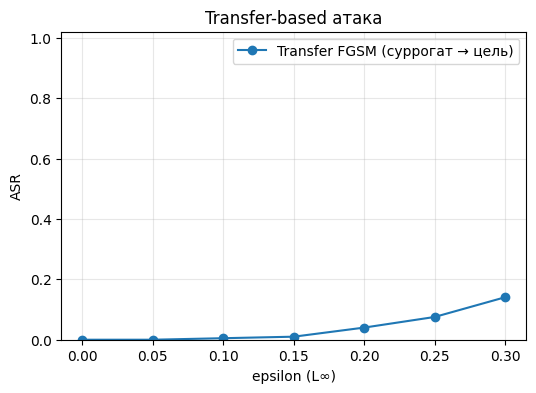

In [ ]:
oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []
crit_ce = nn.CrossEntropyLoss()

x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch[:200].to(device), y_batch[:200].to(device)

# ASR считаем только по примерам, которые цель классифицирует верно (проверка — через оракул)
clean_pred = oracle.label(x_batch)
correct_mask = clean_pred == y_batch
print(f"Верно классифицировано целью: {correct_mask.sum().item()} из {len(y_batch)}")

for eps in epsilons:
    x_adv = fgsm_attack(substitute_model, x_batch, y_batch, eps, crit_ce)  # градиенты ТОЛЬКО суррогата
    pred = oracle.label(x_adv)                                               # проверка на цели через оракул
    asr = (pred[correct_mask] != y_batch[correct_mask]).float().mean().item()
    transfer_asr.append(asr)
    print(f"eps = {eps:.2f}: transfer ASR = {asr:.3f}")
print(f"Запросов к оракулу на этапе атаки: {oracle.n_queries}")

plt.figure(figsize=(6, 4))
plt.plot(epsilons, transfer_asr, "o-", label="Transfer FGSM (суррогат → цель)")
plt.xlabel("epsilon (L∞)"); plt.ylabel("ASR"); plt.ylim(0, 1.02); plt.grid(alpha=.3)
plt.title("Transfer-based атака"); plt.legend(); plt.show()

### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

,epsilon,transfer ASR,white-box ASR,разрыв,доля от white-box
0,0.00,0.000,0.000,0.000,NaN
1,0.05,0.000,0.020,0.020,0.000
2,0.10,0.005,0.121,0.116,0.042
3,0.15,0.010,0.281,0.271,0.036
4,0.20,0.040,0.543,0.503,0.074
5,0.25,0.075,0.764,0.688,0.099
6,0.30,0.141,0.925,0.784,0.152


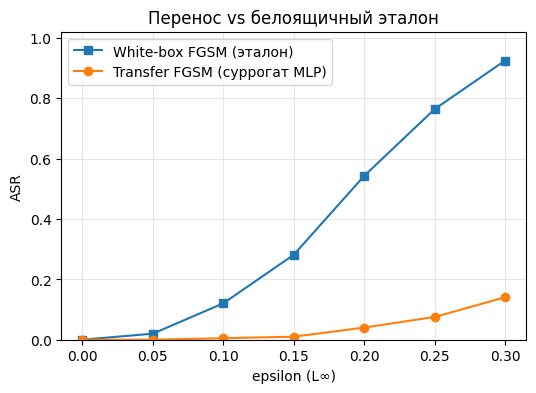

In [ ]:
# White-box эталон: ТОЛЬКО здесь используем градиенты target_model напрямую
whitebox_asr = []
with torch.no_grad():
    wb_correct = target_model(x_batch).argmax(1) == y_batch
for eps in epsilons:
    x_adv_wb = fgsm_attack(target_model, x_batch, y_batch, eps, crit_ce)
    with torch.no_grad():
        pred = target_model(x_adv_wb).argmax(1)
    whitebox_asr.append((pred[wb_correct] != y_batch[wb_correct]).float().mean().item())

gap_df = pd.DataFrame({"epsilon": epsilons, "transfer ASR": transfer_asr, "white-box ASR": whitebox_asr})
gap_df["разрыв"] = gap_df["white-box ASR"] - gap_df["transfer ASR"]
gap_df["доля от white-box"] = gap_df["transfer ASR"] / gap_df["white-box ASR"].replace(0, np.nan)
display(gap_df.round(3))

plt.figure(figsize=(6, 4))
plt.plot(epsilons, whitebox_asr, "s-", label="White-box FGSM (эталон)")
plt.plot(epsilons, transfer_asr, "o-", label="Transfer FGSM (суррогат MLP)")
plt.xlabel("epsilon (L∞)"); plt.ylabel("ASR"); plt.ylim(0, 1.02); plt.grid(alpha=.3)
plt.title("Перенос vs белоящичный эталон"); plt.legend(); plt.show()

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

_Ваш ответ:_

Разрыв огромный и растёт с epsilon (200 тестовых примеров, 199 из них цель классифицирует верно):

| epsilon | transfer ASR | white-box ASR | разрыв |
|---|---|---|---|
| 0.10 | 0.005 | 0.121 | 0.116 |
| 0.20 | 0.040 | 0.543 | 0.503 |
| 0.30 | 0.141 | 0.925 | 0.784 |

Перенос даёт лишь 4–15 % от эффективности белоящичного FGSM. Причины: суррогат — полносвязная сеть, а цель — CNN (разные индуктивные смещения, другая геометрия границ), суррогат видел всего 6400 размеченных точек, а FGSM — одношаговая атака, чувствительная к тому, насколько знак градиента суррогата совпадает со знаком градиента цели.

Связь с согласием суррогата и оракула оказалась слабой. Согласие на **обучающем** наборе на всех раундах 0.99–1.00, то есть этот показатель вообще не информативен: суррогат просто запоминает свои 200…6400 точек. Согласие на тесте росло с 0.839 до 0.877, но transfer ASR@0.3 при этом не вырос (0.21 → 0.22 → 0.14 → 0.15 → 0.13 → 0.14). Совпадение **меток** означает, что суррогат правильно разделяет «далёкие» от границы точки, но для переноса важно совпадение **направлений градиента / нормалей к границе** в окрестности конкретных примеров, а метки об этом почти ничего не говорят. Высокое согласие — необходимое, но не достаточное условие; разрыв с белоящичным эталоном определяется главным образом рассогласованием локальной геометрии границ, а не точностью имитации.

## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

In [ ]:
def _labels_like(y_true, n):
    if torch.is_tensor(y_true) and y_true.numel() > 1:
        return y_true.view(-1).long().to(device)
    return torch.full((n,), int(y_true), dtype=torch.long, device=device)
# минимизировать отрыв правильного класса от лучшего из не правильных
def zoo_loss(probs, y_true, kappa=0.0):
    """C&W-подобная функция на вероятностях: f(x) = max(log p_y - max_{i!=y} log p_i, -kappa).
    f <= 0 (при kappa = 0) означает, что истинный класс уже не top-1."""
    logp = torch.log(probs.clamp_min(1e-300))
    y = _labels_like(y_true, probs.shape[0])
    true_lp = logp.gather(1, y.view(-1, 1)).squeeze(1)
    other = logp.scatter(1, y.view(-1, 1), float("-inf"))
    max_other = other.max(dim=1).values
    return torch.clamp(true_lp - max_other, min=-kappa)

In [ ]:
def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40,
               kappa=0.0, early_stop=True, return_info=False):
    """ZOO (упрощённый, L∞-вариант): покоординатная оценка градиента центральными разностями
    + шаг по знаку оценки (минимизация zoo_loss) + проекция на eps-шар и [0, 1]."""
    shape = x.shape
    x0 = x.detach().to(device).reshape(1, -1)
    d = x0.shape[1]
    x_adv = x0.clone()
    idx = torch.arange(coord_batch, device=device)
    info = {"loss": [], "success": False, "iters": 0}

    for it in range(num_iter):
        coords = torch.randperm(d, device=device)[:coord_batch]         # 1. случайные координаты
        E = torch.zeros(coord_batch, d, device=device)
        E[idx, coords] = h
        batch = torch.cat([x_adv + E, x_adv - E]).reshape(-1, 1, 28, 28)
        losses = zoo_loss(oracle.probs(batch), y_true, kappa)            # 2*coord_batch запросов
        g = (losses[:coord_batch] - losses[coord_batch:]) / (2 * h)     # 2. центральные разности
        x_adv[0, coords] -= alpha * torch.sign(g).float()                # 3. шаг на минимизацию
        x_adv = torch.min(torch.max(x_adv, x0 - epsilon), x0 + epsilon).clamp(0, 1)  # 4. проекция
        info["iters"] = it + 1

        if early_stop:                                                   # 1 запрос: проверка успеха
            p = oracle.probs(x_adv.reshape(1, 1, 28, 28))
            info["loss"].append(zoo_loss(p, y_true, kappa).item())
            if p.argmax(1).item() != int(y_true):
                info["success"] = True
                break

    x_adv = x_adv.reshape(shape)
    return (x_adv, info) if return_info else x_adv

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

Пример #0, истинный класс: 7


ZOO: успех = True, предсказание = 9, итераций = 72, запросов = 5832, L2 = 3.623, L∞ = 0.300, время = 1.43 c


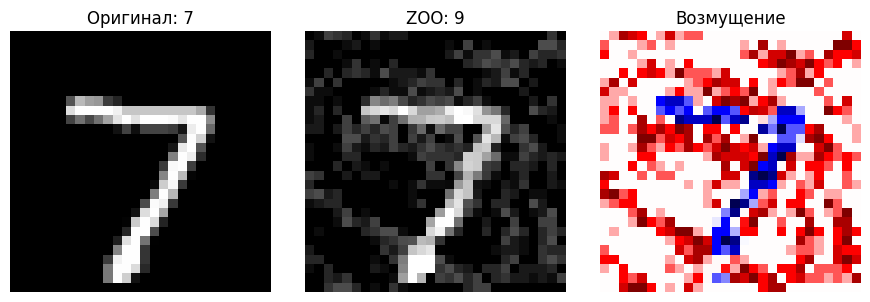

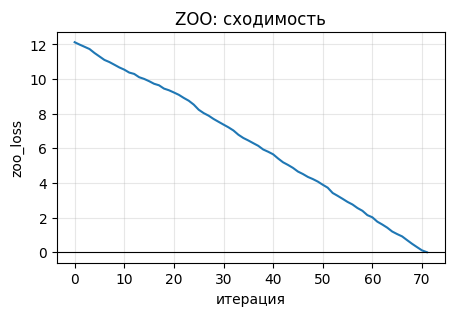

In [ ]:
oracle.reset()

sample_idx = 0
x_sample, y_sample_label = test_dataset[sample_idx]
x_sample = x_sample.unsqueeze(0).to(device)          # 1x1x28x28
assert eval_oracle.label(x_sample).item() == y_sample_label, "выберите верно классифицируемый пример"
print(f"Пример #{sample_idx}, истинный класс: {y_sample_label}")

torch.manual_seed(RANDOM_STATE)
t0 = time.time()
x_zoo, zoo_info = zoo_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05,
                             num_iter=500, h=0.05, coord_batch=40, return_info=True)
zoo_time = time.time() - t0
zoo_queries = oracle.n_queries

zoo_pred = oracle.label(x_zoo).item()               # финальная проверка (1 запрос, вне бюджета атаки)
zoo_success = zoo_pred != y_sample_label
zoo_l2 = (x_zoo - x_sample).norm().item()
zoo_linf = (x_zoo - x_sample).abs().max().item()
print(f"ZOO: успех = {zoo_success}, предсказание = {zoo_pred}, итераций = {zoo_info['iters']}, "
      f"запросов = {zoo_queries}, L2 = {zoo_l2:.3f}, L∞ = {zoo_linf:.3f}, время = {zoo_time:.2f} c")

def show_triplet(x_orig, x_adv, title_adv, y_orig, y_adv):
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    ax[0].imshow(x_orig.squeeze().cpu(), cmap="gray", vmin=0, vmax=1); ax[0].set_title(f"Оригинал: {y_orig}")
    ax[1].imshow(x_adv.squeeze().cpu(), cmap="gray", vmin=0, vmax=1); ax[1].set_title(f"{title_adv}: {y_adv}")
    delta = (x_adv - x_orig).squeeze().cpu()
    m = delta.abs().max().item() + 1e-12
    ax[2].imshow(delta, cmap="seismic", vmin=-m, vmax=m); ax[2].set_title("Возмущение")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

show_triplet(x_sample, x_zoo, "ZOO", y_sample_label, zoo_pred)
plt.figure(figsize=(5, 3)); plt.plot(zoo_info["loss"]); plt.axhline(0, color="k", lw=.8)
plt.xlabel("итерация"); plt.ylabel("zoo_loss"); plt.title("ZOO: сходимость"); plt.grid(alpha=.3); plt.show()

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

In [ ]:
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    """NES с антитетической выборкой: g = 1/(2*sigma*P) * sum_i (L(x+sigma*u_i) - L(x-sigma*u_i)) * u_i.
    Стоимость: 2 * n_samples запросов."""
    shape = x.shape
    x_flat = x.reshape(1, -1)
    u = torch.randn(n_samples, x_flat.shape[1], device=device)
    batch = torch.cat([x_flat + sigma * u, x_flat - sigma * u]).reshape(-1, 1, 28, 28)
    losses = zoo_loss(oracle.probs(batch), y_true).float()
    diff = losses[:n_samples] - losses[n_samples:]
    g = (diff.view(-1, 1) * u).sum(0) / (2 * sigma * n_samples)
    return g.reshape(shape)

In [ ]:
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20,
               early_stop=True, return_info=False):
    """PGD-подобная L∞-атака с NES-оценкой градиента (минимизация zoo_loss)."""
    x0 = x.detach().to(device)
    x_adv = x0.clone()
    info = {"loss": [], "success": False, "iters": 0}
    for it in range(num_iter):
        g = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)
        x_adv = x_adv - alpha * g.sign()
        x_adv = torch.min(torch.max(x_adv, x0 - epsilon), x0 + epsilon).clamp(0, 1)
        info["iters"] = it + 1
        if early_stop:
            p = oracle.probs(x_adv)
            info["loss"].append(zoo_loss(p, y_true).item())
            if p.argmax(1).item() != int(y_true):
                info["success"] = True
                break
    return (x_adv, info) if return_info else x_adv

NES: успех = True, предсказание = 9, итераций = 44, запросов = 1804, L2 = 5.200, L∞ = 0.300, время = 0.57 c


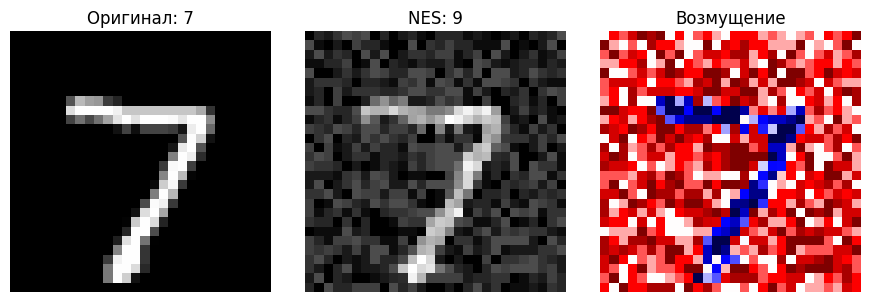

In [ ]:
oracle.reset()
torch.manual_seed(RANDOM_STATE)
t0 = time.time()
x_nes, nes_info = nes_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05,
                             num_iter=500, sigma=0.1, n_samples=20, return_info=True)
nes_time = time.time() - t0
nes_queries = oracle.n_queries

nes_pred = oracle.label(x_nes).item()
nes_success = nes_pred != y_sample_label
nes_l2 = (x_nes - x_sample).norm().item()
nes_linf = (x_nes - x_sample).abs().max().item()
print(f"NES: успех = {nes_success}, предсказание = {nes_pred}, итераций = {nes_info['iters']}, "
      f"запросов = {nes_queries}, L2 = {nes_l2:.3f}, L∞ = {nes_linf:.3f}, время = {nes_time:.2f} c")
show_triplet(x_sample, x_nes, "NES", y_sample_label, nes_pred)

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

,метод,успех,L2,Linf,запросов,итераций,время_с
0,ZOO,True,3.623,0.3,5832,72,1.428
1,NES,True,5.200,0.3,1804,44,0.565


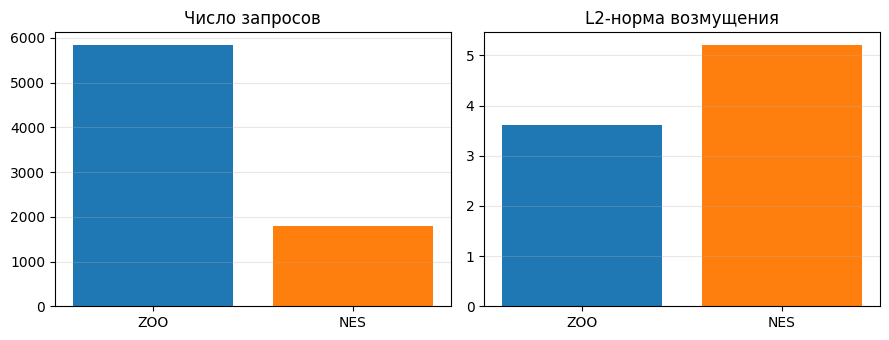

Статистика по 20 изображениям (eps = 0.3):


,успех,запросов_среднее,запросов_медиана,L2_среднее
метод,,,,
NES,0.95,1847.05,779.0,4.493
ZOO,1.00,4511.70,4617.0,2.829


In [ ]:
score_df = pd.DataFrame([
    dict(метод="ZOO", успех=zoo_success, L2=zoo_l2, Linf=zoo_linf, запросов=zoo_queries,
         итераций=zoo_info["iters"], время_с=zoo_time),
    dict(метод="NES", успех=nes_success, L2=nes_l2, Linf=nes_linf, запросов=nes_queries,
         итераций=nes_info["iters"], время_с=nes_time),
])
display(score_df.round(3))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].bar(score_df["метод"], score_df["запросов"], color=["tab:blue", "tab:orange"]); ax[0].set_title("Число запросов")
ax[1].bar(score_df["метод"], score_df["L2"], color=["tab:blue", "tab:orange"]); ax[1].set_title("L2-норма возмущения")
for a in ax: a.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

# Один пример — шумная оценка, поэтому дополнительно усредним по 20 верно классифицируемым тестовым изображениям
n_eval = 20
eval_ids = [i for i in range(1, 200) if target_test_pred[i] == y_test_all[i]][:n_eval]
rows = []
for i in eval_ids:
    xi, yi = x_test_all[i:i + 1], y_test_all[i].item()
    for name, fn in [("ZOO", lambda: zoo_attack(oracle, xi, yi, 0.3, 0.05, 500, 0.05, 40, return_info=True)),
                     ("NES", lambda: nes_attack(oracle, xi, yi, 0.3, 0.05, 500, 0.1, 20, return_info=True))]:
        oracle.reset(); torch.manual_seed(i)
        xa, inf = fn()
        rows.append(dict(метод=name, idx=i, успех=inf["success"], запросов=oracle.n_queries,
                         L2=(xa - xi).norm().item()))
multi_df = pd.DataFrame(rows)
score_multi = multi_df.groupby("метод").agg(успех=("успех", "mean"),
                                           запросов_среднее=("запросов", "mean"),
                                           запросов_медиана=("запросов", "median"),
                                           L2_среднее=("L2", "mean"))
print(f"Статистика по {n_eval} изображениям (eps = 0.3):")
display(score_multi.round(3))

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

_Ваш ответ:_

Меньше запросов потратил **NES**: на примере #0 — 1804 запроса против 5832 у ZOO; в среднем по 20 изображениям — 1847 против 4512 (медиана 779 против 4617). Успешность сопоставима (NES 95 %, ZOO 100 % за ≤ 500 итераций), зато у ZOO возмущение меньше (средняя L2 2.83 против 4.49).

Причина — в структуре оценки градиента:
- **ZOO** оценивает производную по одной координате за 2 запроса. Полный градиент для d = 784 стоит 1568 запросов, а за итерацию (80 запросов) мы узнаём только 40 из 784 компонент. Изменяются лишь эти 40 пикселей, поэтому нужно много итераций, пока наберётся достаточный сдвиг; зато «лишние» пиксели не трогаются, и L2 получается небольшой.
- **NES** за те же 2 запроса на сэмпл получает проекцию градиента на случайное направление **во всём пространстве**. 20 антитетических пар дают грубую, но ненулевую оценку всех 784 компонент сразу, а при sign-шаге важна только корреляция знаков с истинным градиентом. Градиент MNIST-классификатора сосредоточен в небольшом подпространстве (штрихи цифры и их окрестности), так что даже малое число случайных направлений хорошо его «ловит». Цена — шаг по знаку меняет почти все пиксели на ±alpha, возмущение быстро доходит до углов eps-куба, и L2 выше.

Итог: при ограниченном бюджете запросов выгоднее NES; если важна минимальная заметность возмущения, выгоднее ZOO (особенно с importance sampling, см. С2).

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

In [ ]:
def is_adversarial(oracle, x, true_label):
    """Decision-based доступ: только факт «top-1 метка != истинной»."""
    return bool(oracle.label(x).item() != int(true_label))

In [ ]:
def boundary_attack(oracle, x_orig, true_label, x_init, num_steps=200, init_delta=0.1, init_epsilon=0.1,
                    init_binary_search=True, return_queries=False):
    """Упрощённая Boundary Attack (Brendel et al., 2018) — работает только с top-1 меткой."""
    x_orig = x_orig.detach().to(device)
    x_adv = x_init.detach().clone().to(device)
    assert is_adversarial(oracle, x_adv, true_label), "стартовая точка должна быть adversarial"

    # Стандартный первый шаг: бинарный поиск на отрезке [x_orig, x_init] до ближайшей adversarial-точки
    if init_binary_search:
        lo, hi = 0.0, 1.0
        for _ in range(12):
            mid = (lo + hi) / 2
            if is_adversarial(oracle, x_orig + mid * (x_adv - x_orig), true_label):
                hi = mid
            else:
                lo = mid
        x_adv = x_orig + hi * (x_adv - x_orig)

    delta, epsilon = init_delta, init_epsilon
    history, q_history = [(x_adv - x_orig).norm().item()], [oracle.n_queries]

    for step in range(num_steps):
        diff = x_adv - x_orig
        dist = diff.norm()
        # --- ортогональный шаг: случайный шум ⟂ diff, затем проекция на сферу радиуса dist вокруг x_orig
        eta = torch.randn_like(x_adv)
        d_unit = diff / dist
        eta = eta - (eta * d_unit).sum() * d_unit
        eta = eta / eta.norm() * delta * dist
        cand = x_adv + eta
        cand = x_orig + (cand - x_orig) * dist / (cand - x_orig).norm()
        cand = cand.clamp(0, 1)

        if is_adversarial(oracle, cand, true_label):
            # --- шаг к исходному изображению (сокращение расстояния на долю epsilon)
            towards = (cand + epsilon * (x_orig - cand)).clamp(0, 1)
            if is_adversarial(oracle, towards, true_label):
                x_adv = towards
                delta, epsilon = delta * 1.05, epsilon * 1.1
            else:
                x_adv = cand
                delta, epsilon = delta * 1.05, epsilon * 0.8
        else:
            delta, epsilon = delta * 0.9, epsilon * 0.9
        delta = float(np.clip(delta, 1e-3, 1.0))
        epsilon = float(np.clip(epsilon, 1e-4, 0.5))

        history.append((x_adv - x_orig).norm().item())
        q_history.append(oracle.n_queries)

    return (x_adv, history, q_history) if return_queries else (x_adv, history)

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [ ]:
oracle.reset()
torch.manual_seed(RANDOM_STATE)
# случайный равномерный шум; перегенерируем, пока он не станет adversarial
while True:
    x_init = torch.rand_like(x_sample)
    if is_adversarial(oracle, x_init, y_sample_label):
        break
print(f"x_init adversarial: {is_adversarial(oracle, x_init, y_sample_label)}, "
      f"метка = {oracle.label(x_init).item()}, L2 до оригинала = {(x_init - x_sample).norm().item():.3f}")
oracle.reset()

t0 = time.time()
x_ba, ba_history, ba_q_history = boundary_attack(oracle, x_sample, y_sample_label, x_init,
                                                 num_steps=5000, init_delta=0.1, init_epsilon=0.1,
                                                 return_queries=True)
ba_time = time.time() - t0
ba_queries = oracle.n_queries

ba_pred = oracle.label(x_ba).item()
ba_success = ba_pred != y_sample_label
ba_l2 = (x_ba - x_sample).norm().item()
ba_linf = (x_ba - x_sample).abs().max().item()
print(f"Boundary Attack: успех = {ba_success}, предсказание = {ba_pred}, запросов = {ba_queries}, "
      f"L2 = {ba_l2:.3f}, L∞ = {ba_linf:.3f}, время = {ba_time:.2f} c")
for k in [0, 100, 500, 1000, 2000, 5000]:
    print(f"  шаг {k:5d}: L2 = {ba_history[k]:.3f}, запросов = {ba_q_history[k]}")

x_init adversarial: True, метка = 3, L2 до оригинала = 15.341


Boundary Attack: успех = True, предсказание = 3, запросов = 8352, L2 = 4.448, L∞ = 0.688, время = 4.84 c
  шаг     0: L2 = 8.247, запросов = 13
  шаг   100: L2 = 7.860, запросов = 172
  шаг   500: L2 = 6.469, запросов = 846
  шаг  1000: L2 = 5.509, запросов = 1682
  шаг  2000: L2 = 5.081, запросов = 3357
  шаг  5000: L2 = 4.448, запросов = 8352


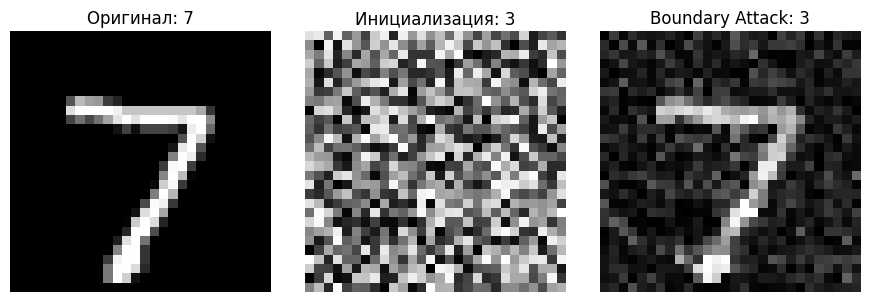

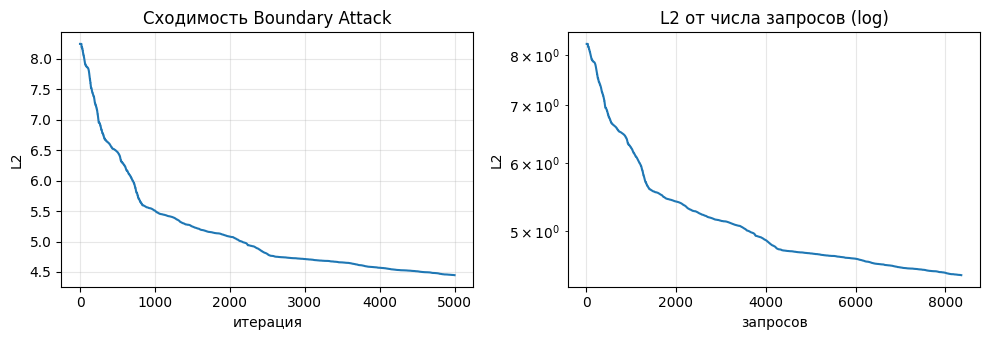

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for a, img, t in zip(ax, [x_sample, x_init, x_ba],
                     [f"Оригинал: {y_sample_label}", f"Инициализация: {eval_oracle.label(x_init).item()}",
                      f"Boundary Attack: {ba_pred}"]):
    a.imshow(img.squeeze().cpu(), cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(ba_history); ax[0].set_xlabel("итерация"); ax[0].set_ylabel("L2")
ax[0].set_title("Сходимость Boundary Attack"); ax[0].grid(alpha=.3)
ax[1].plot(ba_q_history, ba_history); ax[1].set_xlabel("запросов"); ax[1].set_ylabel("L2")
ax[1].set_yscale("log"); ax[1].set_title("L2 от числа запросов (log)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

_Ваш ответ:_

Decision-based атака видит только top-1 метку, то есть кусочно-постоянную функцию входа. Почти всюду её градиент равен нулю, а конечная разность ненулевая только тогда, когда пробная точка пересекает границу решения. Каждый запрос даёт не более одного бита («adversarial / нет»), а не вещественное значение функции потерь. Поэтому нельзя оценить ни величину, ни (в стандартной Boundary Attack) направление градиента. Остаётся случайное блуждание вдоль границы с отбраковкой (rejection sampling): предложить шаг и оставить его, если метка сохранилась.

Следствия видны в эксперименте. Старт после бинарного поиска — L2 = 8.25, через 1000 шагов — 5.51, через 2000 — 5.08, через 5000 шагов (8352 запроса) — 4.45, и кривая всё ещё не вышла на плато. У score-based ZOO при сопоставимом бюджете (5832 запроса) L2 = 3.62. Сходимость медленная, потому что в размерности d = 784 случайное ортогональное направление почти ортогонально и нормали к границе: доля полезных предложений мала, и по мере приближения к исходному изображению шаги delta и epsilon приходится уменьшать, так что прогресс за итерацию падает. Число итераций растёт примерно пропорционально размерности и требуемой точности. HopSkipJump (С3) решает именно эту проблему: он оценивает направление нормали по знакам в батче случайных проб и сходится в несколько раз быстрее.

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [ ]:
# Transfer-based: FGSM на суррогате для того же изображения, eps = 0.3 (тот же L∞-бюджет, что у ZOO/NES)
oracle.reset()
x_tr = fgsm_attack(substitute_model, x_sample, torch.tensor([y_sample_label], device=device), 0.3, crit_ce)
tr_pred = oracle.label(x_tr).item()            # единственный запрос к цели
tr_queries = oracle.n_queries
tr_success = tr_pred != y_sample_label
tr_l2 = (x_tr - x_sample).norm().item()
tr_linf = (x_tr - x_sample).abs().max().item()

summary = pd.DataFrame([
    dict(метод="Transfer FGSM", доступ="метки (для обучения суррогата)", успех=tr_success,
         L2=tr_l2, Linf=tr_linf, запросов_атаки=tr_queries,
         запросов_всего=tr_queries + n_queries_substitute),
    dict(метод="ZOO", доступ="вероятности", успех=zoo_success, L2=zoo_l2, Linf=zoo_linf,
         запросов_атаки=zoo_queries, запросов_всего=zoo_queries),
    dict(метод="NES", доступ="вероятности", успех=nes_success, L2=nes_l2, Linf=nes_linf,
         запросов_атаки=nes_queries, запросов_всего=nes_queries),
    dict(метод="Boundary Attack", доступ="top-1 метка", успех=ba_success, L2=ba_l2, Linf=ba_linf,
         запросов_атаки=ba_queries, запросов_всего=ba_queries),
])
summary.to_csv("lab6_summary.csv", index=False)
print("Таблица сохранена в lab6_summary.csv  (запросов_всего для transfer включает обучение суррогата)")
summary.round(3)

Таблица сохранена в lab6_summary.csv  (запросов_всего для transfer включает обучение суррогата)


,метод,доступ,успех,L2,Linf,запросов_атаки,запросов_всего
0,Transfer FGSM,метки (для обучения суррогата),False,6.191,0.300,1,6401
1,ZOO,вероятности,True,3.623,0.300,5832,5832
2,NES,вероятности,True,5.200,0.300,1804,1804
3,Boundary Attack,top-1 метка,True,4.448,0.688,8352,8352


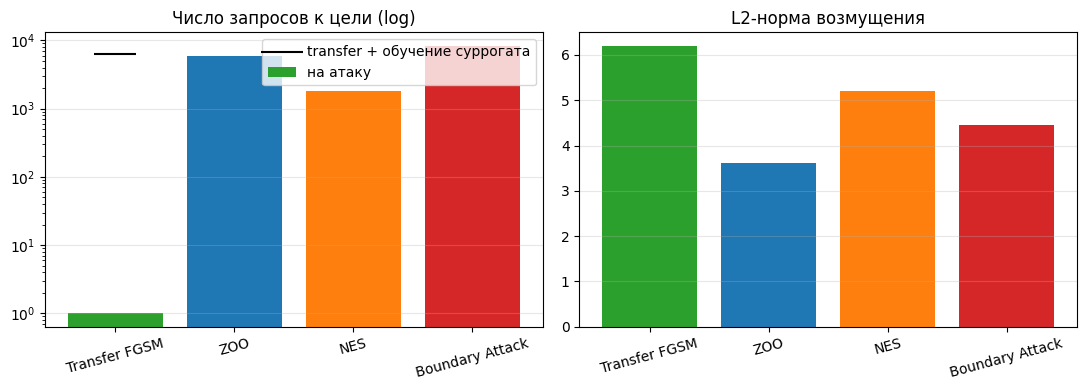

In [ ]:
colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(summary["метод"], summary["запросов_атаки"], color=colors, label="на атаку")
ax[0].scatter(summary["метод"][:1], summary["запросов_всего"][:1], marker="_", s=900, c="k",
              label="transfer + обучение суррогата")
ax[0].set_yscale("log"); ax[0].set_title("Число запросов к цели (log)"); ax[0].legend()
ax[1].bar(summary["метод"], summary["L2"], color=colors); ax[1].set_title("L2-норма возмущения")
for a in ax:
    a.grid(axis="y", alpha=.3); a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

_Ваш ответ:_

Итоговая таблица для примера #0 (истинная «7»):

| метод | успех | L2 | запросов к цели |
|---|---|---|---|
| Transfer FGSM (eps = 0.3) | нет | 6.19 | 1 (+6400 на обучение суррогата) |
| ZOO | да | 3.62 | 5832 |
| NES | да | 5.20 | 1804 |
| Boundary Attack | да | 4.45 (L∞ = 0.69) | 8352 |

**(а) Полные вероятности, лимита на запросы нет → score-based атака.** Вероятности дают вещественный сигнал функции потерь, и градиент оценивается напрямую. Без ограничения бюджета лучше всего ZOO (с importance sampling): у неё наименьшая L2 и 100 % успеха. Если важны время и количество запросов, выбирают NES: примерно в 2.5 раза дешевле при сопоставимом успехе. Transfer здесь избыточен и менее надёжен.

**(б) Только top-1 метка и жёсткий лимит → decision-based атака, но улучшенного типа (HopSkipJump), желательно с хорошей инициализацией.** Score-based методы неприменимы: нет вещественного сигнала. Boundary Attack гарантирует успех (старт уже adversarial), но качество определяется бюджетом: за ~170 запросов L2 ≈ 7.9, то есть возмущение очень заметное. HSJA достигает тех же уровней L2 в 5–6 раз быстрее (С3). Если есть возможность обучить суррогат, его adversarial-пример полезно использовать как стартовую точку вместо шума: так экономится первая, самая дорогая часть пути.

**(в) Можно offline собрать небольшой размеченный набор того же домена → transfer-based атака.** Суррогат обучается без запросов к цели, а сама атака стоит 1 запрос (проверку) на пример. Это единственный вариант, который почти не оставляет следов в логах API. Наш эксперимент показывает и слабое место: MLP → CNN с одношаговым FGSM переносится плохо (ASR 14 % при eps = 0.3, для этого примера атака не удалась). На практике надо брать суррогат похожей архитектуры или ансамбль, усиливать переносимость (momentum / input diversity) и, если лимит позволяет, дорабатывать перенесённый пример несколькими score- или decision-based запросами.

Общий принцип: чем богаче доступная информация (градиенты → вероятности → метка → ничего), тем меньше запросов и искажения нужно; метод выбирается под самый богатый доступный канал.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

_Ваш ответ:_

Три класса чёрно-ящичных атак по-разному «покупают» информацию о локальной геометрии границы решения цели:
- **transfer-based** не покупает её вообще: он заимствует её у суррогата и надеется, что границы похожи. Запросов почти нет, но успех зависит от сходства моделей (у нас 14 % против 92 % белоящичного эталона при eps = 0.3; целевой перенос почти нулевой, С1);
- **score-based** (ZOO, NES) покупает вещественные значения потерь и восстанавливает градиент конечными разностями. Надёжно (95–100 %), но нужны тысячи запросов;
- **decision-based** (Boundary, HSJA) покупает по одному биту на запрос. Работает при самом бедном API, но медленнее всех сходится к малому возмущению.

Почему перенос вообще возможен. Модели, обученные на одном распределении, аппроксимируют одно и то же многообразие данных. Вблизи него их границы решений ориентированы похоже: нормаль к границе в основном определяется тем, в каких направлениях от многообразия меняется класс, а не архитектурой. Adversarial-направления лежат в пространстве большой размерности, общем для разных моделей («пространство переносимых примеров»), а граница у данных слабо искривлена. Поэтому линейное приближение (FGSM) у одной модели указывает туда же, куда и у другой. Там, где кривизна велика и границы моделей расходятся (узкие целевые области классов, итеративные атаки, «подгоняющиеся» под частную кривизну суррогата), перенос ломается. Это объясняет, почему у нас нецелевой одношаговый перенос работает лучше целевого и итеративного.

Почему adversarial training (PGD) помогает и против чёрного ящика. Все изученные атаки — это разные оценки **одной и той же** величины: направления к ближайшей точке другого класса внутри допустимого шара. PGD-обучение не прячет градиент (в отличие от gradient masking, которое чёрно-ящичные атаки как раз обходят), а действительно отодвигает границу от данных и сглаживает функцию потерь в eps-окрестности. Если в шаре радиуса eps adversarial-точек нет или их очень мало, то их не найдёт ни точный градиент, ни оценка по конечным разностям, ни NES, ни блуждание по границе. Кроме того, у робастной модели сглаженная граница, опирающаяся на «человеческие» признаки, меньше похожа на границы обычных суррогатов, поэтому падает и переносимость. Защита против сильнейшего (белоящичного) противника автоматически покрывает более слабых, чёрно-ящичных: их информация о модели — подмножество белоящичной.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


С1. Нецелевой vs целевой перенос (200 тестовых примеров, цель = (y+1) mod 10)


,epsilon,нецелевой transfer ASR,целевой transfer (FGSM),целевой transfer (I-FGSM),I-FGSM: доля ошибок цели (любая метка),целевой успех на самом суррогате,целевой white-box I-FGSM
0,0.1,0.005,0.000,0.000,0.000,0.392,0.010
1,0.2,0.040,0.000,0.000,0.005,0.955,0.603
2,0.3,0.141,0.015,0.005,0.015,0.995,0.990


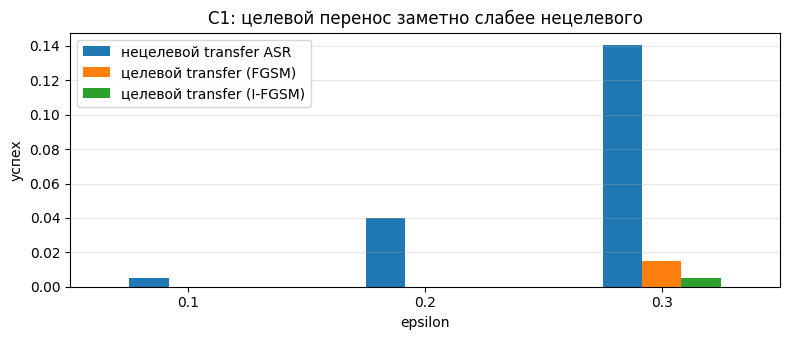

In [ ]:
# С1 — см. ниже; С2 и С3 — в следующих ячейках
# =====================================================================
# С1. Целевая (targeted) transfer-based атака
# =====================================================================
def targeted_fgsm(model, x, target, epsilon):
    """Целевой FGSM: шаг ПРОТИВ градиента CE по целевому классу."""
    x = x.clone().detach().requires_grad_(True)
    grad, = torch.autograd.grad(F.cross_entropy(model(x), target), x)
    return torch.clamp(x - epsilon * grad.sign(), 0, 1).detach()

def targeted_ifgsm(model, x, target, epsilon, n_iter=10):
    """Итеративный целевой FGSM (PGD без случайного старта)."""
    alpha = epsilon / 4
    x0, x_adv = x.detach(), x.detach().clone()
    for _ in range(n_iter):
        x_adv.requires_grad_(True)
        grad, = torch.autograd.grad(F.cross_entropy(model(x_adv), target), x_adv)
        x_adv = x_adv.detach() - alpha * grad.sign()
        x_adv = torch.min(torch.max(x_adv, x0 - epsilon), x0 + epsilon).clamp(0, 1)
    return x_adv.detach()

target_cls = (y_batch + 1) % 10          # целевой класс: (y + 1) mod 10
m = correct_mask
rows = []
for eps in [0.1, 0.2, 0.3]:
    oracle.reset()
    untargeted = (oracle.label(fgsm_attack(substitute_model, x_batch, y_batch, eps, crit_ce))[m] != y_batch[m]).float().mean().item()
    pred_t1 = oracle.label(targeted_fgsm(substitute_model, x_batch, target_cls, eps))
    pred_t2 = oracle.label(targeted_ifgsm(substitute_model, x_batch, target_cls, eps))
    # белоящичный эталон целевой атаки (градиенты цели — только для сравнения)
    x_wb = targeted_ifgsm(target_model, x_batch, target_cls, eps)
    x_sub = targeted_ifgsm(substitute_model, x_batch, target_cls, eps)
    with torch.no_grad():
        pred_wb = target_model(x_wb).argmax(1)
        sub_hit = (substitute_model(x_sub).argmax(1) == target_cls)[m].float().mean().item()
    rows.append({"epsilon": eps,
                 "нецелевой transfer ASR": untargeted,
                 "целевой transfer (FGSM)": (pred_t1[m] == target_cls[m]).float().mean().item(),
                 "целевой transfer (I-FGSM)": (pred_t2[m] == target_cls[m]).float().mean().item(),
                 "I-FGSM: доля ошибок цели (любая метка)": (pred_t2[m] != y_batch[m]).float().mean().item(),
                 "целевой успех на самом суррогате": sub_hit,
                 "целевой white-box I-FGSM": (pred_wb[m] == target_cls[m]).float().mean().item()})
c1_df = pd.DataFrame(rows)
print("С1. Нецелевой vs целевой перенос (200 тестовых примеров, цель = (y+1) mod 10)")
display(c1_df.round(3))

c1_plot = c1_df.set_index("epsilon")[["нецелевой transfer ASR", "целевой transfer (FGSM)", "целевой transfer (I-FGSM)"]]
c1_plot.plot(kind="bar", figsize=(8, 3.5), rot=0); plt.ylabel("успех"); plt.grid(axis="y", alpha=.3)
plt.title("С1: целевой перенос заметно слабее нецелевого"); plt.tight_layout(); plt.show()

С2. ZOO: равномерный выбор координат vs importance sampling (20 изображений, eps = 0.3)


,успех,запросов_среднее,запросов_медиана,L2_среднее
метод,,,,
ZOO (importance),1.0,3094.2,3118.5,2.47
ZOO (равномерно),1.0,4511.7,4617.0,2.83


Медианное отношение запросов importance/равномерно по изображениям: 0.64; importance дешевле на 19 из 20 изображений


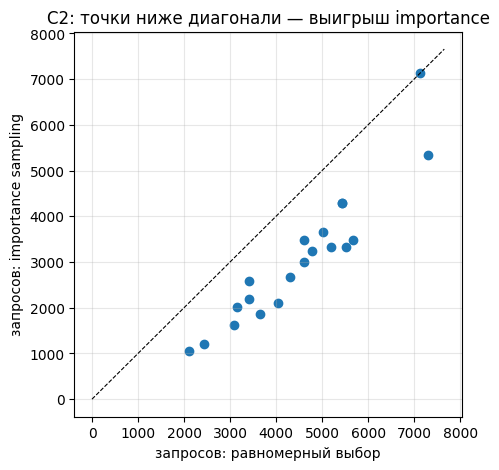

In [ ]:
# =====================================================================
# С2. Importance sampling в ZOO
# =====================================================================
def zoo_attack_is(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=500, h=0.05, coord_batch=40,
                  mix_uniform=0.2, ema=0.7, return_info=False):
    """ZOO с неравномерным выбором координат.
    Вес пикселя = априорный вес «вблизи штрихов цифры» (дилатация изображения)
                  + скользящее среднее |оценки градиента| с предыдущих итераций.
    Смешиваем с равномерным распределением (mix_uniform), чтобы не терять исследование."""
    shape = x.shape
    x0 = x.detach().to(device).reshape(1, -1)
    d = x0.shape[1]
    x_adv = x0.clone()
    idx = torch.arange(coord_batch, device=device)

    img = x.detach().to(device).reshape(1, 1, 28, 28)
    near_digit = F.max_pool2d(img, kernel_size=5, stride=1, padding=2).reshape(-1)   # окрестность штрихов
    prior = 0.1 + near_digit                       # фон тоже возможен, но реже
    prior = prior / prior.mean()
    grad_mag = torch.zeros(d, device=device)       # накопленная важность координат
    info = {"loss": [], "success": False, "iters": 0}

    for it in range(num_iter):
        imp = prior * (1 + grad_mag / (grad_mag.mean() + 1e-12))
        p = (1 - mix_uniform) * imp / imp.sum() + mix_uniform / d
        coords = torch.multinomial(p, coord_batch, replacement=False)
        E = torch.zeros(coord_batch, d, device=device)
        E[idx, coords] = h
        batch = torch.cat([x_adv + E, x_adv - E]).reshape(-1, 1, 28, 28)
        losses = zoo_loss(oracle.probs(batch), y_true)
        g = ((losses[:coord_batch] - losses[coord_batch:]) / (2 * h)).float()
        grad_mag[coords] = ema * grad_mag[coords] + (1 - ema) * g.abs()
        x_adv[0, coords] -= alpha * torch.sign(g)
        x_adv = torch.min(torch.max(x_adv, x0 - epsilon), x0 + epsilon).clamp(0, 1)
        info["iters"] = it + 1
        pr = oracle.probs(x_adv.reshape(1, 1, 28, 28))
        info["loss"].append(zoo_loss(pr, y_true).item())
        if pr.argmax(1).item() != int(y_true):
            info["success"] = True
            break
    x_adv = x_adv.reshape(shape)
    return (x_adv, info) if return_info else x_adv

rows = []
for i in eval_ids:                              # те же 20 изображений, что и в п.3.4
    xi, yi = x_test_all[i:i + 1], y_test_all[i].item()
    for name, fn in [("ZOO (равномерно)", zoo_attack), ("ZOO (importance)", zoo_attack_is)]:
        oracle.reset(); torch.manual_seed(i)
        xa, inf = fn(oracle, xi, yi, epsilon=0.3, alpha=0.05, num_iter=500, h=0.05, coord_batch=40, return_info=True)
        rows.append(dict(метод=name, idx=i, успех=inf["success"], запросов=oracle.n_queries,
                         L2=(xa - xi).norm().item()))
c2_raw = pd.DataFrame(rows)
c2_df = c2_raw.groupby("метод").agg(успех=("успех", "mean"), запросов_среднее=("запросов", "mean"),
                                    запросов_медиана=("запросов", "median"), L2_среднее=("L2", "mean"))
print("С2. ZOO: равномерный выбор координат vs importance sampling (20 изображений, eps = 0.3)")
display(c2_df.round(2))

piv = c2_raw.pivot(index="idx", columns="метод", values="запросов")
ratio = (piv["ZOO (importance)"] / piv["ZOO (равномерно)"])
print(f"Медианное отношение запросов importance/равномерно по изображениям: {ratio.median():.2f}; "
      f"importance дешевле на {int((ratio < 1).sum())} из {len(ratio)} изображений")

plt.figure(figsize=(5, 5))
plt.scatter(piv["ZOO (равномерно)"], piv["ZOO (importance)"])
lim = [0, piv.values.max() * 1.05]; plt.plot(lim, lim, "k--", lw=.8)
plt.xlabel("запросов: равномерный выбор"); plt.ylabel("запросов: importance sampling")
plt.title("С2: точки ниже диагонали — выигрыш importance"); plt.grid(alpha=.3); plt.show()

### Результаты дополнительных заданий (выполнены С1, С2, С3)

**С1. Целевой перенос.** При eps = 0.3 нецелевой перенос FGSM даёт ASR 14.1 %, а целевой (класс (y+1) mod 10) — лишь 1.5 % (FGSM) и 0.5 % (I-FGSM). На самом суррогате целевой I-FGSM успешен в 99.5 % случаев, белоящичный целевой I-FGSM на цели — в 99 %. Значит, дело не в силе атаки: целевые примеры «переобучаются» под конкретную границу суррогата. Нецелевой атаке достаточно выйти из области истинного класса в любую сторону (большое общее подпространство направлений), а целевая должна попасть в узкую область конкретного класса, которая у двух моделей с разной архитектурой расположена по-разному. Это согласуется с утверждением лекции об ограниченной переносимости целевых атак. Показательно и то, что итеративный I-FGSM переносится даже хуже одношагового FGSM: он точнее подстраивается под кривизну суррогата.

**С2. Importance sampling в ZOO.** Выбор координат с приоритетом окрестности штрихов цифры и пикселей с большой |оценкой градиента| на прошлых итерациях (плюс 20 % равномерного выбора) при 100 % успехе сократил средние затраты с 4512 до 3094 запросов (~−31 %, медианное отношение 0.64, выигрыш на 19 из 20 изображений) и дополнительно уменьшил L2 (2.47 против 2.83). Запросы перестают тратиться на пиксели фона, которые почти не влияют на решение CNN.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
